In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import json
import os
import shutil
import seaborn as sns
import numpy as np
import gzip
from Bio import SeqIO
import sys, shlex
from unittest.mock import patch
# defaults
import time
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import sys, shlex
from unittest.mock import patch

In [3]:
depins2025_file = './data/dePins2025.xlsx'
depins = pd.ExcelFile(depins2025_file)

published = depins.parse('Supplementary_Data_1')
assessed  = depins.parse('Supplementary_Data_2')

seed_sequence = 'MALDQTNRYSDLSLKEDELIASGDYVLCAYLMKPKSGYGYLEAAAHFAAESSTGTNVEVSTTDDFTKGVDALVYEIDEAKELMKIAYPVDLFDINIIDGRAMLASFLTLTIGNNQGMGDIEYAKMLDFYMPPKYLRLYDGPAVNIQDMWRILGRPIENGGYIAGTIIKPKLGLRPEPFAEAAYQFWLGGDFIKNDEPQGNQPFSPMKKTIPLVADAMRRAQDETGEAKLFSANITADDPAEMIARGEFVLETFGFEASQVAFLVDGYVAGPTAVATARRNFPNQFLHFHRAGHGAVTSPQSKRGYTAFVHIKMTRLLGASGMHVGTMGYGKMEGEASDKLIAYMIERDSADGPFYHQEWAGMKPTTPIISGGMNALRLPGFFENLGHGNVINTAGGGTYGHIDSPAAGAVSLRQAYECWKEGADPVEYAKEHKEFARAFESFPHDADAIFPGWRDKLGVHK'
L = len(seed_sequence)

# PARSE AFDB SEARCH RESULTS
afdb_hits = pd.read_csv( './data/AAC38280.1_AFDB_hits.csv')
afdb_hits['delta'] = (L-afdb_hits['Sequence length (target)']) / L
afdb_hits = afdb_hits[afdb_hits['delta'] < 0.1]
afdb_hits = afdb_hits.iloc[::2].iloc[:50]
afdb_hits['UniProtIDs'] = afdb_hits['AFDB accession'].str.split('-').str[1]
AFDB_targets = afdb_hits['UniProtIDs']#.tolist()

# PARSE MGnify SEARCH RESULTS
mgnify_hits = pd.read_csv( './data/AAC38280.1_MGnify_hits.tsv', sep='\t' )
mgnify_hits['delta'] = np.abs(mgnify_hits['Target Length']-mgnify_hits['Query Length'])/mgnify_hits['Query Length']
mgnify_hits = mgnify_hits.loc[mgnify_hits['delta']<0.1]
MGnify_targets = mgnify_hits.iloc[:50]['Target Name']#.tolist()

# save targets to file
all_targets = pd.concat([MGnify_targets,AFDB_targets])
target_rubisco_file = './rubiscos.txt'
all_targets.to_csv(target_rubisco_file,index=False, header=False)

In [4]:
AFDB_targets.to_csv('./AFDB_rubisco.txt',index=False, header=False)
MGnify_targets.to_csv('./MGnify_rubisco.txt',index=False, header=False)

# Let's snap : )

In [5]:
# settings libraries
from gcsnap.rich_console import RichConsole
from gcsnap.utils import CustomLogger
from gcsnap.configuration import Configuration
from gcsnap.targets import Target
from gcsnap.genomic_context import GenomicContext

from gcsnap.providers.ncbi.make import Maker as NCBI_Maker
from gcsnap.providers.MGnify.make import Maker as MGnify_Maker

from gcsnap.annotations.families import Families
from gcsnap.annotations.operons import Operons

from gcsnap.providers.ncbi.make import Maker as ncbiMaker
from gcsnap.annotations.taxonomy import SourMashBinning

#from gcsnap.visual.runner import Figures
#from gcsnap.annotations.de_novo import DeNovo

/scicore/home/schwede/pasqua0002/miniforge3/envs/GCsnap/lib/python3.11/site-packages/jsonapi_client/__init__.py:32: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [13]:
# Initial logging configuration
CustomLogger.configure_loggers()

console = RichConsole('base')
console.print_title()

# A. Parse configuration and arguments
config_file_path = '../config_private_A.yaml'
config = Configuration(config_path=config_file_path)
print("Configuration defaults loaded and parser is ready.")
print(f"Default n_flanking5: {config.arguments['n_flanking5']['value']}")

---------------------------------------------

metaGCsnap

metaGCsnap is a helps you explore and analyze metagenomic data from a protein-centric perspective.

Thanks for using it! 🇨🇭 ❤️🤍❤️ 🇨🇭

---------------------------------------------

✅  Done configuration file config.yaml loaded

✅  Done parsing CLI arguments and config.yaml

Configuration defaults loaded and parser is ready.
Default n_flanking5: 4


In [14]:
#cmd = f"""python3 metaGCsnap.py --targets {target_rubisco_file} --out-label {metagcsnap_results}"""


In [15]:
out_label          = '/scicore/home/schwede/pasqua0002/metaGCsnap/workflow/allSnap/tutorial/rubisco'
ncbi_targets_file  = './tutorial/AFDB_rubisco.txt'
mgnify_targets_file = './tutorial/MGnify_rubisco.txt'

cmd = (
    f"gcsnap "
    f"--out-label {out_label} "
    f"--ncbi-targets {ncbi_targets_file} "
    f"--mgnify-targets {mgnify_targets_file}"
)

simulated_argv = shlex.split(cmd)   # first token is the program name

try:
    with patch.object(sys, 'argv', simulated_argv):
        config.parse_arguments()
    print("✅ Configuration parsed.")
except SystemExit:
    print("⚠️  argparse exited (e.g., --help or unknown flag).")
except Exception as e:
    print(f"❌ Error: {e}")

RichConsole.set_out_label(out_label)

✅ Configuration parsed.


In [16]:
targets = Target(config)

targets.add_provider_targets(out_label, 'ncbi', AFDB_targets.tolist())
targets.add_provider_targets(out_label, 'mgnify', MGnify_targets.tolist())

In [17]:
# Run MGnify
MGnify_runner = MGnify_Maker(config, targets, console)
MGnify_gc = MGnify_runner.get_genomic_context()

✅  Done genomic context file already present, reading from disk.

In [18]:
ncbi_runner = NCBI_Maker(config, targets, console)
ncbi_gc = ncbi_runner.get_genomic_context()

✅  Done genomic context file already present, reading from disk.

In [19]:
gc = GenomicContext(config, out_label)

if gc.all_init_files_present:
    gc.load_from_files(targets.all_ids)
else:
    # merge genomic context from providers
    gc.curr_targets = targets.all_ids
    gc.update_syntenies(ncbi_gc.get_syntenies())
    gc.update_syntenies(MGnify_gc.get_syntenies())

    # detect protein familis
    families = Families(config, gc, out_label, sensitivity=7.5 )
    families.run()

    # write protein families results
    gc.update_syntenies(families.get_families())
    gc.create_and_write_families_summary(families)
    console.print_done('Protein families assigned')

    # detect operons
    operons = Operons(config, gc, out_label)
    operons.run()

    # write operons results
    gc.update_syntenies(operons.get_operons())
    gc.create_and_write_operon_types_summary()
    gc.find_most_populated_operon_types() 

    # detect genomic bins
    binning = SourMashBinning(gc=gc, config=config)
    binning.run()

    # write dna binning results
    gc.update_syntenies(binning.gc.syntenies)
    gc.create_and_write_metagenomic_bins_summary()
    gc.find_most_populated_metagenomic_bins() 

✅  Done loaded syntenies from genomic_context_information.json

✅  Done loaded families from families_summary.json

✅  Done loaded selected operons from selected_operons.json

        Set most populated operon to: GC Type 00004

✅  Done loaded selected metagenomic bins from selected_metagenomic_bins.json

        Set current targets to provided list (100 targets)

        Re-creating operon types summary from loaded syntenies...

✅  Done create operons summary

        Found 17 operon types (out of a total of 39 input targets)

# Integration showcase 1: add taxonomy from Kraken

In [20]:
def extract_rank_data(df, rank_letter):
    # 1. Split the strings into lists
    names_list = df['lineage_names'].str.split(';')
    ids_list = df['lineage_ids'].str.split(';')
    
    # 2. Find the index of the element starting with your rank_letter (e.g., 'c__')
    # We use a lambda to find the index of the first string that starts with the prefix
    prefix = f"{rank_letter}__"
    
    def get_info(row_names, row_ids):
        for i, name in enumerate(row_names):
            if name.startswith(prefix):
                # Clean the name (remove 'c__') and get corresponding ID
                clean_name = name.replace(prefix, "")
                clean_id = row_ids[i]
                return clean_name, clean_id
        return None, None

    # Apply the logic row-wise
    extracted = [get_info(n, i) for n, i in zip(names_list, ids_list)]
    
    # Create temporary columns for easy dict conversion
    df[['temp_name', 'temp_id']] = pd.DataFrame(extracted, index=df.index)
    
    # 3. Convert to the specific dictionary format
    result_dict = df.set_index('genomic_region')[['temp_name', 'temp_id']].rename(
        columns={'temp_name': 'taxon_name', 'temp_id': 'taxon_id'}
    ).to_dict(orient='index')
    
    return result_dict

In [21]:
kraken = pd.read_csv( os.path.join(out_label, 'kraken','kraken2_output.tsv'), sep='\t')

contig_2_taxon = extract_rank_data(kraken, 'o')

updated_gc_taxonomy = gc.syntenies.copy()

for k,v in updated_gc_taxonomy.items():
    try:
        v['taxonomy']=contig_2_taxon[v['assembly_metadata']['genomic_region']]
    except KeyError:
        v['taxonomy'] = {'taxon_name': 'root', 'taxon_id': '1'}

gc.update_syntenies(updated_gc_taxonomy)

In [22]:
# deliver final syntenies
gc.write_syntenies_to_json()

✅  Done syntenies information written to 
/scicore/home/schwede/pasqua0002/metaGCsnap/workflow/allSnap/tutorial/rubisco/genomic_context/results/genomic_conte
xt_information.json

In [23]:
from gcsnap.visual.runner import Figures
from gcsnap.annotations.de_novo import DeNovo

In [24]:
figs = Figures(config, gc, out_label)

figs.run_static()

Output()

legend saved → visuals/genomic_context_legend.png

✅  Done creating static genomic context figure

        Static genomic context figures created

In [25]:
from gcsnap.visual.dna_context import draw_dna_context
draw_dna_context(gc, figs.family_colors, figs.reference_family,
                 sort_mode='operon', out_dir=figs.out_dir, initial_window=40)

'/scicore/home/schwede/pasqua0002/metaGCsnap/workflow/allSnap/tutorial/rubisco/visuals/operon_dna_context.html'

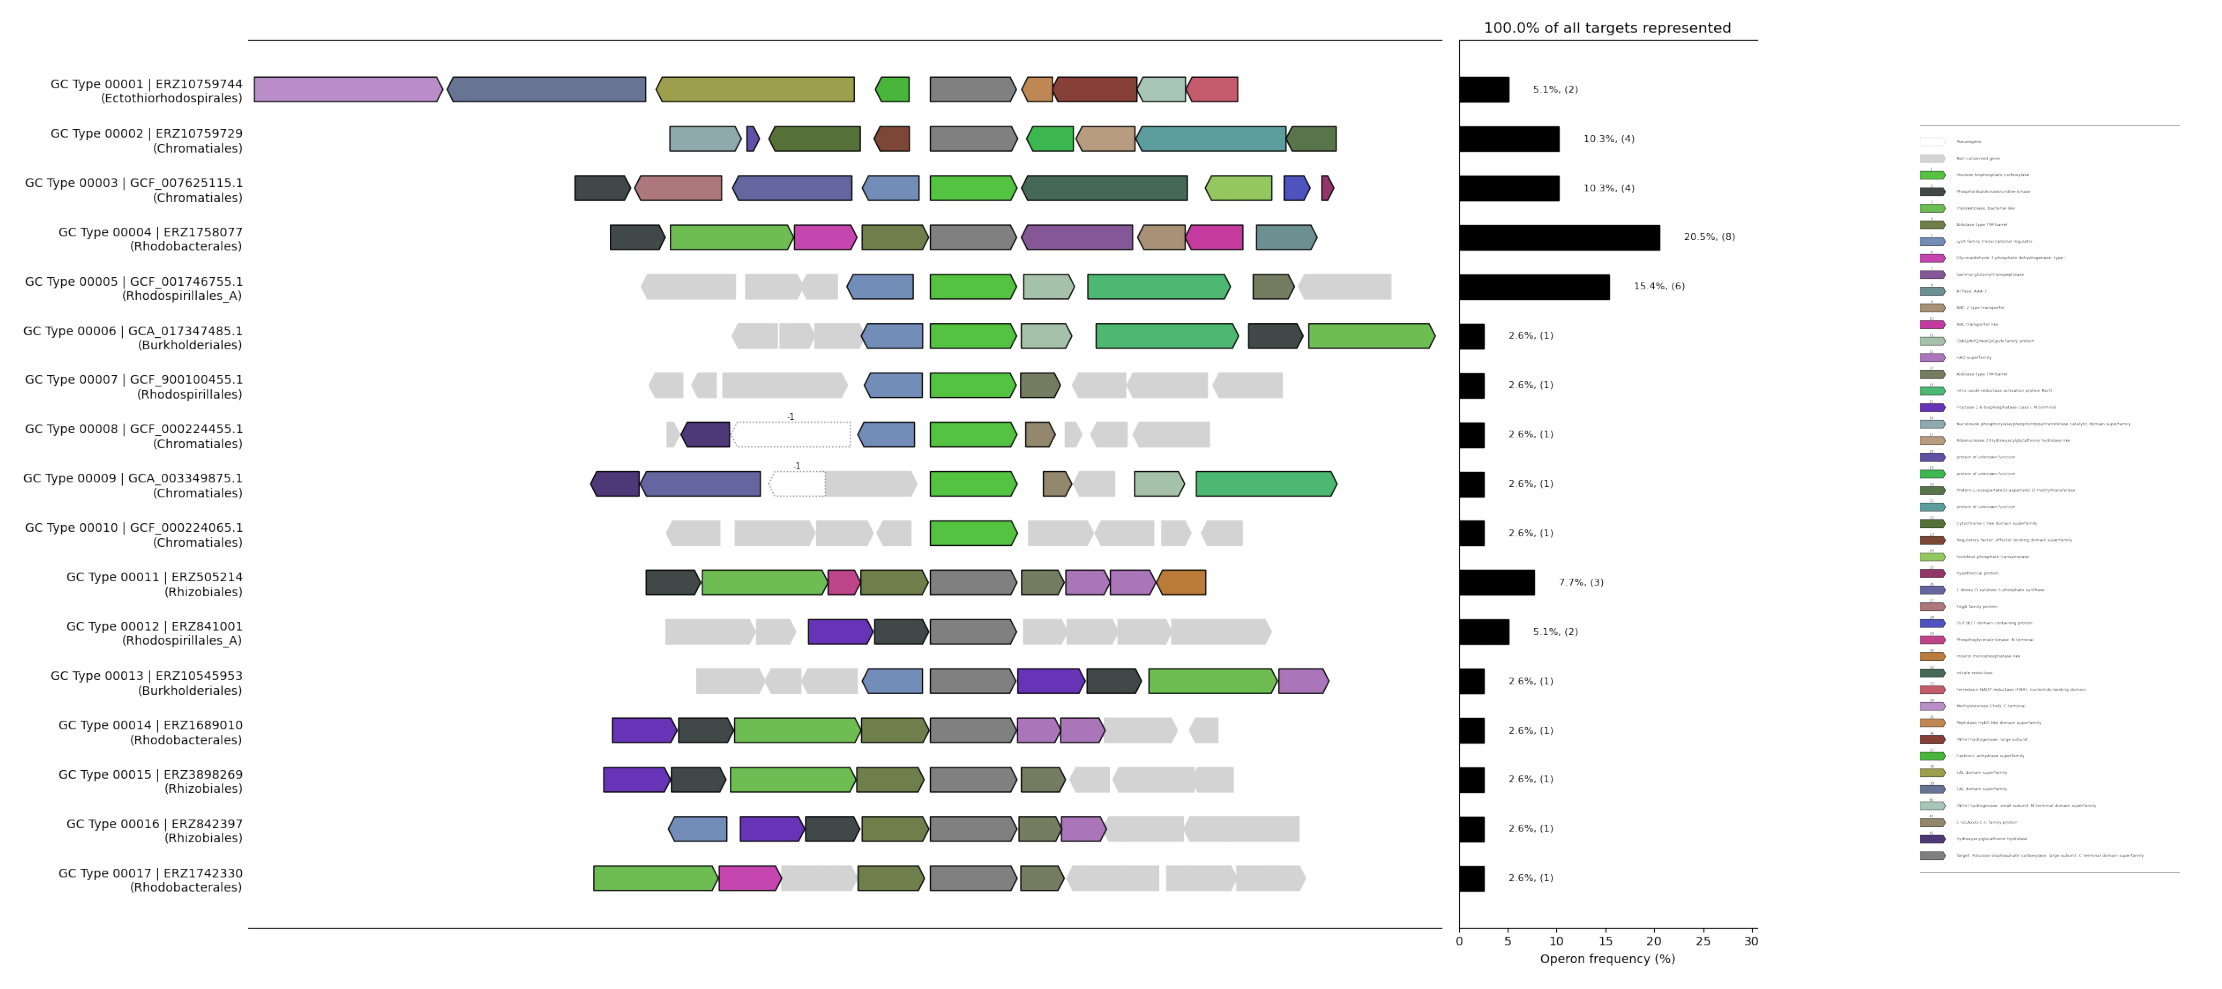

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(24, 10), gridspec_kw={'width_ratios': [3, 1]})

axes[0].imshow(mpimg.imread(f'{figs.out_dir}/genomic_context.png'))
axes[0].axis('off')

axes[1].imshow(mpimg.imread(f'{figs.out_dir}/genomic_context_legend.png'))
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [27]:
figs.run_interactive(sort_mode='metagenomic bins')
figs.run_interactive(sort_mode='operon')

Output()

✅  Done creating interactive figure (sort_mode='metagenomic bins')

Output()

✅  Done creating interactive figure (sort_mode='operon')

'/scicore/home/schwede/pasqua0002/metaGCsnap/workflow/allSnap/tutorial/rubisco/visuals/operon_interactive.html'

In [28]:
figs.run_advanced(group_by='operon', sort_mode='operon', gc_legend_mode='assembly',select_groups=[2,3,4,5,7])

gc.summarize_operon([2,3,4,5,7])

Output()

✅  Done creating advanced interactive figure (group_by='operon', sort_mode='operon')

        Advanced interactive figure saved to visuals/advanced_operon.html

✅  Done operon summaries written to 
/scicore/home/schwede/pasqua0002/metaGCsnap/workflow/allSnap/tutorial/rubisco/genomic_context/operon_summaries (5 
operon(s))

In [29]:
#path = figs.run_advanced(sort_mode='operon', gc_legend_mode='assembly')
figs.run_advanced(group_by='metagenomic_bins', sort_mode='metagenomic_bins', gc_legend_mode='assembly')

Output()

✅  Done creating advanced interactive figure (group_by='metagenomic_bins', sort_mode='metagenomic_bins')

        Advanced interactive figure saved to visuals/advanced_metagenomic_bins.html

'/scicore/home/schwede/pasqua0002/metaGCsnap/workflow/allSnap/tutorial/rubisco/visuals/advanced_metagenomic_bins.html'

In [30]:
# subset + custom name
figs.run_advanced(group_by='metagenomic_bins', sort_mode='metagenomic bins',
                  select_groups=[1, 2, 5],
                  out_filename='my_subset_bins.html')

✅  Done creating advanced interactive figure (group_by='metagenomic_bins', sort_mode='metagenomic bins')

        Advanced interactive figure saved to visuals/my_subset_bins.html

'/scicore/home/schwede/pasqua0002/metaGCsnap/workflow/allSnap/tutorial/rubisco/visuals/my_subset_bins.html'

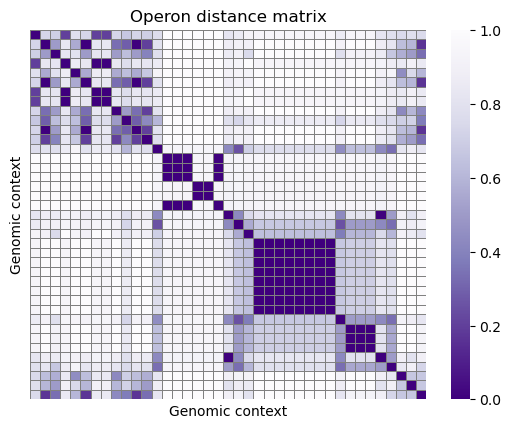

In [31]:
operon_distance  = pd.read_csv(gc.operon_distance_matrix_file,compression='gzip',index_col='target')

sns.heatmap(operon_distance, xticklabels=False, yticklabels=False, cmap='Purples_r', linecolor='grey', linewidth=0.5)
plt.xlabel('Genomic context')
plt.ylabel('Genomic context')
plt.title('Operon distance matrix')
plt.show()

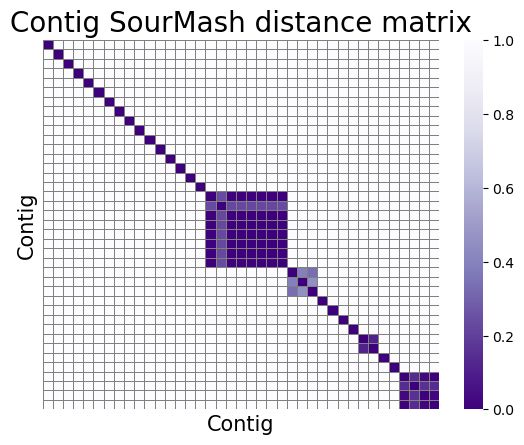

In [32]:
operon_distance  = pd.read_csv(gc.metagenomic_bins_distance_matrix_file,compression='gzip',index_col='target')

sns.heatmap(operon_distance, xticklabels=False, yticklabels=False, cmap='Purples_r', linecolor='grey', linewidth=0.5)
plt.xlabel('Contig',fontsize=15)
plt.ylabel('Contig',fontsize=15)
plt.title('Contig SourMash distance matrix',fontsize=20)
plt.show()

## Getting the biome distribution just takes few lines of code

Text(0, 0.5, 'Biome')

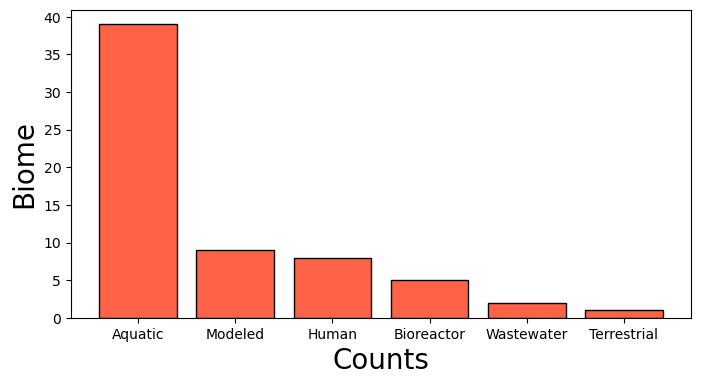

In [33]:
MGnify_assembly_metadata_file = MGnify_runner.dataset.assembly_metadata_file
MGnify_assembly_metadata = pd.read_csv(MGnify_assembly_metadata_file)

n = 2
MGnify_assembly_metadata['biome_full'] = MGnify_assembly_metadata['relationships.biomes.data'].apply(lambda x: eval(x)[0]['id'] if pd.notnull(x) and len(eval(x)) > 0 else None)
MGnify_assembly_metadata['biome'] = MGnify_assembly_metadata['biome_full'].str.split(':').apply(lambda x: x[n] if isinstance(x, list) and len(x) > n else None)
biome_count = MGnify_assembly_metadata['biome'].value_counts()

fig, axes = plt.subplots(1, 1, figsize=(8, 4))
axes.bar(biome_count.index, biome_count.values, color='tomato',edgecolor='black')

axes.set_xlabel('Counts', fontsize=20, color='black')
axes.set_ylabel('Biome', fontsize=20, color='black')

## So far we got the whole experiment/ assembly. To really access the gebnomic context of our target protein, we need to isolate its contig (fraction of genome). 
## The Contigs class extract the DNA sequences, the coding sequences and organize them in .gff files.

## The contigs class extract the dna/ coding sequences from the respecive assembly files and prepares the gff files for the genomic coordinates

# A typical quality metric for metagenomic contigs is their length (the longer the more genome-like)

In [34]:
contigs = {'ncbi':[],'MGnify':[]}

for k,v in gc.syntenies.items():

    source = v['assembly_metadata']['source']

    if source=='ncbi':
        contigs['ncbi'].append( v['assembly_metadata']['dna_file'] )
    elif source=='MGnify':
        contigs['MGnify'].append( v['assembly_metadata']['dna_file'] )

In [35]:
contigs = {'ncbi':[],'MGnify':[]}

for k,v in gc.syntenies.items():

    source = v['assembly_metadata']['source']

    if source=='ncbi':
        contigs['ncbi'].append( v['assembly_metadata']['dna_file'] )
    elif source=='MGnify':
        contigs['MGnify'].append( v['assembly_metadata']['dna_file'] )
        
lengths_data = {}

for source, file_list in contigs.items():
    lengths = pd.Series(dtype=int) # Explicit dtype to avoid pandas warnings
    for fasta_file in file_list:
        with gzip.open(fasta_file, "rt") as handle:
            for record in SeqIO.parse(handle, "fasta"):
                lengths[record.id] = len(record.seq)   
    lengths_data[source] = lengths.sort_values(ascending=False)

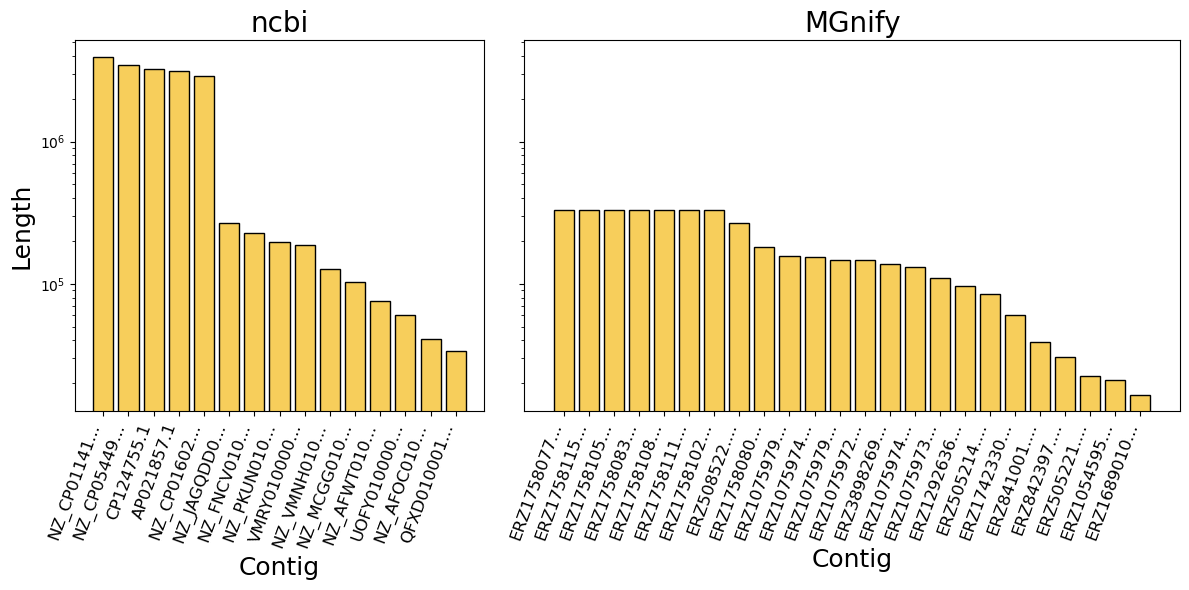

In [36]:
counts = [len(lengths) for lengths in lengths_data.values()]
counts = [c if c > 0 else 1 for c in counts]

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True, gridspec_kw={'width_ratios': counts})

source_colors = {'ncbi': '#F7CE5B', 'MGnify': '#F7CE5B'}

for ax, (source, lengths) in zip(axes, lengths_data.items()):
    
    ax.bar(lengths.index, lengths.values, color=source_colors.get(source, '#F7CE5B'), edgecolor='black')
    
    ax.set_title(f'{source}', fontsize=20)
    ax.set_xlabel('Contig', fontsize=18)
    
    new_labels = []
    for label in lengths.index:
        lbl = str(label)
        if len(lbl) > 10:
            lbl = lbl[:10] + "..."
        new_labels.append(lbl)
        
    ax.set_xticks(range(len(new_labels)))
    ax.set_xticklabels(new_labels, rotation=70, ha='right', fontsize=12)
    ax.set_yscale('log')
    
axes[0].set_ylabel('Length', fontsize=18) 

plt.tight_layout()
plt.show()

In [37]:
#pd.Series([ g['assembly_metadata']['dna_file'] for g in gc.syntenies.values() ]).to_csv('contigs.txt',index=False,header=False)

In [38]:
# submti your proteins to your favorite functional annotation tool. Here, you can find the output for GhostKOALA https://www.kegg.jp/ghostkoala/

In [39]:
GhostKOALA_out_label = os.path.join( out_label , 'GhostKOALA' )
GhostKOALA = pd.read_csv( os.path.join(GhostKOALA_out_label,'user_ko_definition.txt'),sep='\t',comment='#', header=None, names=['cds_code','annotation_id','annotation_name','confidence','second_best','second_best_confidence'])
GhostKOALA = GhostKOALA[['cds_code','annotation_id','annotation_name','confidence']]
GhostKOALA = GhostKOALA.dropna(subset=['annotation_id'])
GhostKOALA['cds_code'] = GhostKOALA['cds_code'].str.split('|').str[0]
koala_file = os.path.join(GhostKOALA_out_label, 'ghostkoala.tsv')
GhostKOALA.to_csv(koala_file, index=False, sep='\t')

In [46]:
GhostKOALA

,cds_code,annotation_id,annotation_name,confidence
1,WP_005959997.1,K01069,"gloB, gloC, HAGH; hydroxyacylglutathione hydro...",262.0
3,WP_039959748.1,K21703,"cbbR, cmpR, ndhR; LysR family transcriptional ...",311.0
4,WP_005960001.1,K01601,"rbcL, cbbL; ribulose-bisphosphate carboxylase ...",466.0
7,WP_005960006.1,K06193,phnA; protein PhnA,184.0
8,WP_005960008.1,K11473,glcF; glycolate dehydrogenase iron-sulfur subu...,493.0
...,...,...,...,...
359,ERZ10759738.261-NODE-261-length-110240-cov-41....,K00573,"E2.1.1.77, pcm; protein-L-isoaspartate(D-aspar...",195.0
364,ERZ10759744.16-NODE-16-length-154674-cov-83.37...,K01601,"rbcL, cbbL; ribulose-bisphosphate carboxylase ...",439.0
368,ERZ10759744.16-NODE-16-length-154674-cov-83.37...,K00573,"E2.1.1.77, pcm; protein-L-isoaspartate(D-aspar...",195.0
373,ERZ10759792.29-NODE-29-length-148016-cov-85.83...,K01601,"rbcL, cbbL; ribulose-bisphosphate carboxylase ...",439.0


In [40]:
koala = DeNovo(config, gc, koala_file, GhostKOALA_out_label)
koala.run()
koala_gc = koala.get_annotated_gc()

✅  Done assigning de novo families from annotation file

✅  Done create families summary

        Found 61 conserved protein families, 3 pseudogenes and 103 non-conserved protein coding regions

✅  Done families information written to mmseqs_flanking/families_summary.json

In [45]:
koala_gc.families

{-1: {'name': 'pseudogene',
  'members': ['RIFP1SYM_RS04775', 'DIZ79_07580', 'HUE57_RS00100'],
  'all_names': ['pseudogene', 'pseudogene', 'pseudogene']},
 0: {'name': 'Non-conserved',
  'members': ['WP_005959996.1',
   'WP_005960002.1',
   'WP_005960004.1',
   'WP_139134947.1',
   'WP_069958102.1',
   'WP_069958095.1',
   'WP_007041873.1',
   'WP_007041870.1',
   'WP_007041868.1',
   'WP_007041865.1',
   'WP_144358986.1',
   'WP_144358991.1',
   'WP_144358992.1',
   'TVT54528.1',
   'TVT54522.1',
   'TVT54521.1',
   'WP_046860478.1',
   'WP_046860473.1',
   'WP_199930403.1',
   'WP_046860472.1',
   'VAX05770.1',
   'VAX05760.1',
   'VAX05753.1',
   'RDH90987.1',
   'RDH91002.1',
   'WP_176787811.1',
   'WGZ90036.1',
   'WGZ90032.1',
   'WGZ90031.1',
   'WGZ90030.1',
   'WP_273438203.1',
   'WP_273438210.1',
   'WP_273438211.1',
   'WP_066099393.1',
   'WP_066099396.1',
   'BBO21788.1',
   'WP_078483592.1',
   'WP_078483594.1',
   'WP_078483595.1',
   'WP_078483598.1',
   'WP_078483599

In [41]:
koala_operons = Operons(config, koala_gc, GhostKOALA_out_label)
koala_operons.run()
koala_gc.update_syntenies(koala_operons.get_operons())
koala_gc.create_and_write_operon_types_summary()
koala_gc.find_most_populated_operon_types()

# Persist final syntenies
koala_gc.write_syntenies_to_json()

console.print_done( f'De novo annotation complete. Results written to {koala_gc.out_label}' )

✅  Done running standard operon clustering

✅  Done create operons summary

        Found 23 operon types (out of a total of 39 input targets)

✅  Done find most populated operon types

        Selected 23 operon/genomic_context types, with most populated corresponding to GC Type 00014

✅  Done selected operon written to 
/scicore/home/schwede/pasqua0002/metaGCsnap/workflow/allSnap/tutorial/rubisco/GhostKOALA/genomic_context/results/se
lected_operons.json

✅  Done syntenies information written to 
/scicore/home/schwede/pasqua0002/metaGCsnap/workflow/allSnap/tutorial/rubisco/GhostKOALA/genomic_context/results/ge
nomic_context_information.json

✅  Done de novo annotation complete. Results written to 
/scicore/home/schwede/pasqua0002/metaGCsnap/workflow/allSnap/tutorial/rubisco/GhostKOALA

Output()

static figure saved → visuals/genomic_context.png

legend saved → visuals/genomic_context_legend.png

✅  Done creating static genomic context figure

        Static genomic context figures created

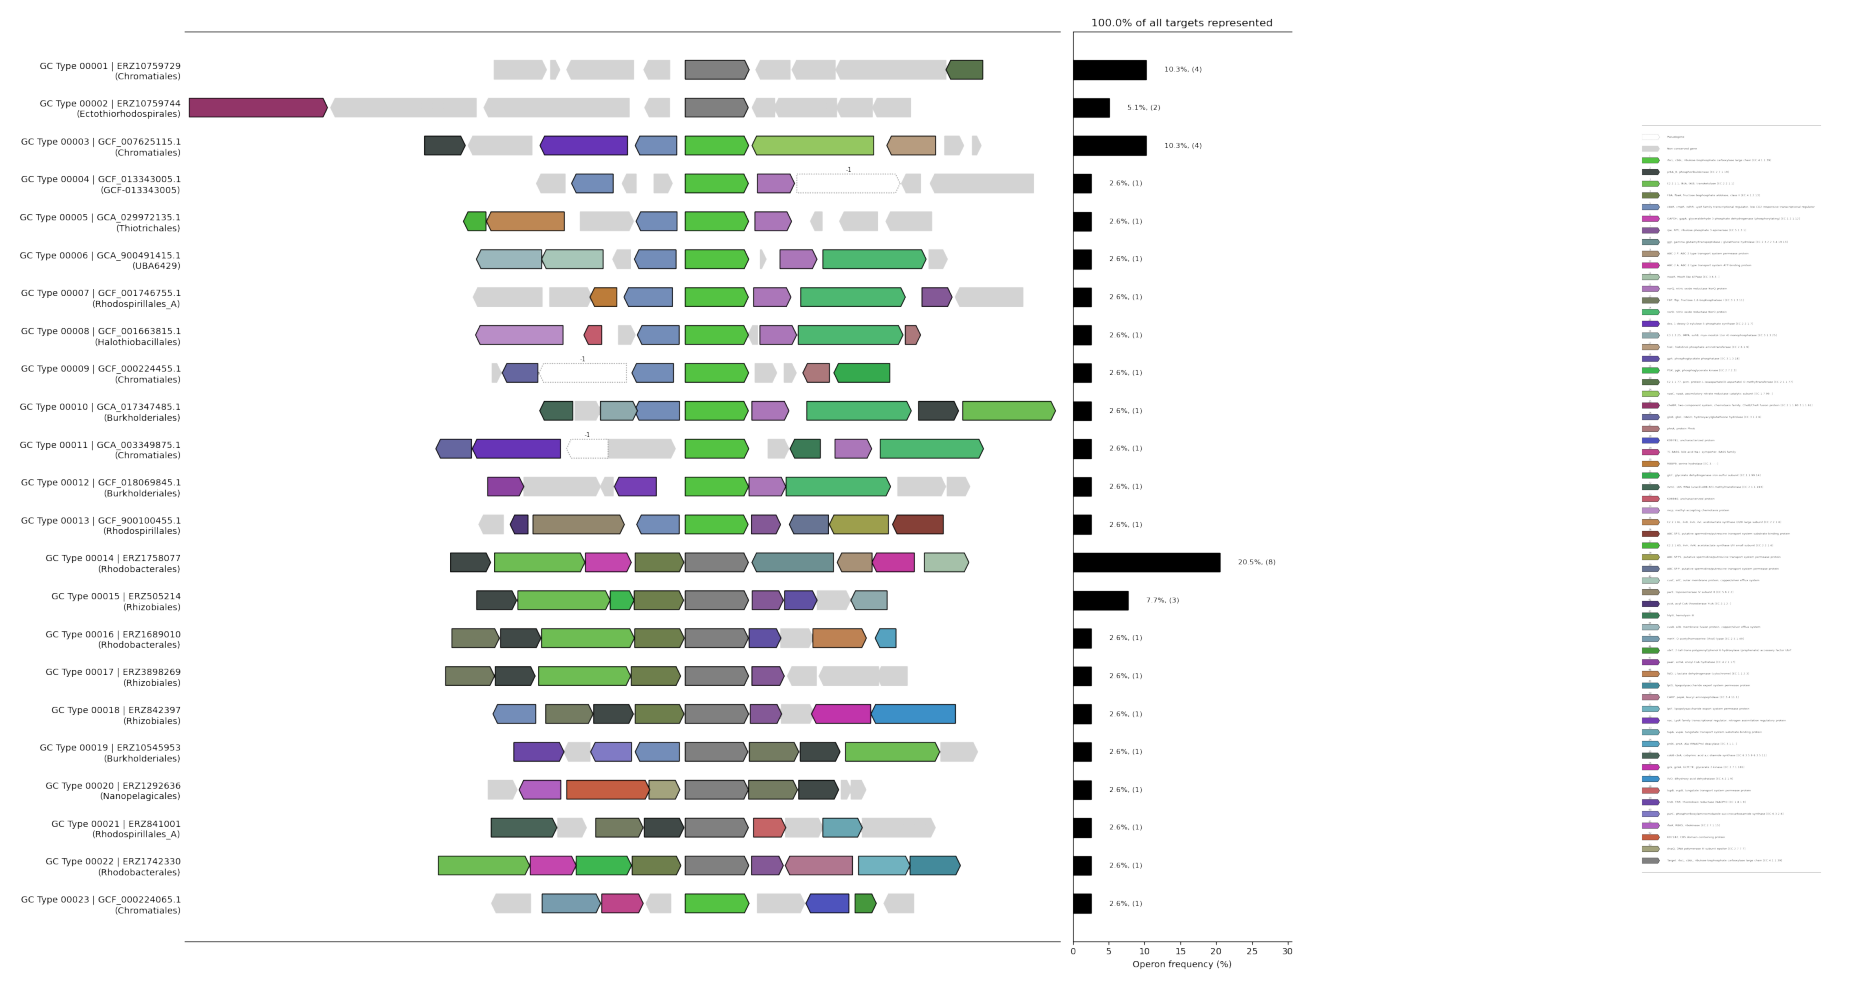

In [42]:
koala_figs = Figures(config, koala_gc, GhostKOALA_out_label)

koala_figs.run_static()

fig, axes = plt.subplots(1, 2, figsize=(24, 10), gridspec_kw={'width_ratios': [3, 1]})

axes[0].imshow(mpimg.imread(f'{koala_figs.out_dir}/genomic_context.png'))
axes[0].axis('off')

axes[1].imshow(mpimg.imread(f'{koala_figs.out_dir}/genomic_context_legend.png'))
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [43]:
koala_figs.run_interactive(sort_mode='operon')
figs.run_advanced(group_by='operon', sort_mode='operon', gc_legend_mode='assembly',select_groups=[14,15,16])
gc.summarize_operon([14,15,16])

Output()

✅  Done creating interactive figure (sort_mode='operon')

Output()

✅  Done creating advanced interactive figure (group_by='operon', sort_mode='operon')

        Advanced interactive figure saved to visuals/advanced_operon.html

✅  Done operon summaries written to 
/scicore/home/schwede/pasqua0002/metaGCsnap/workflow/allSnap/tutorial/rubisco/genomic_context/operon_summaries (3 
operon(s))

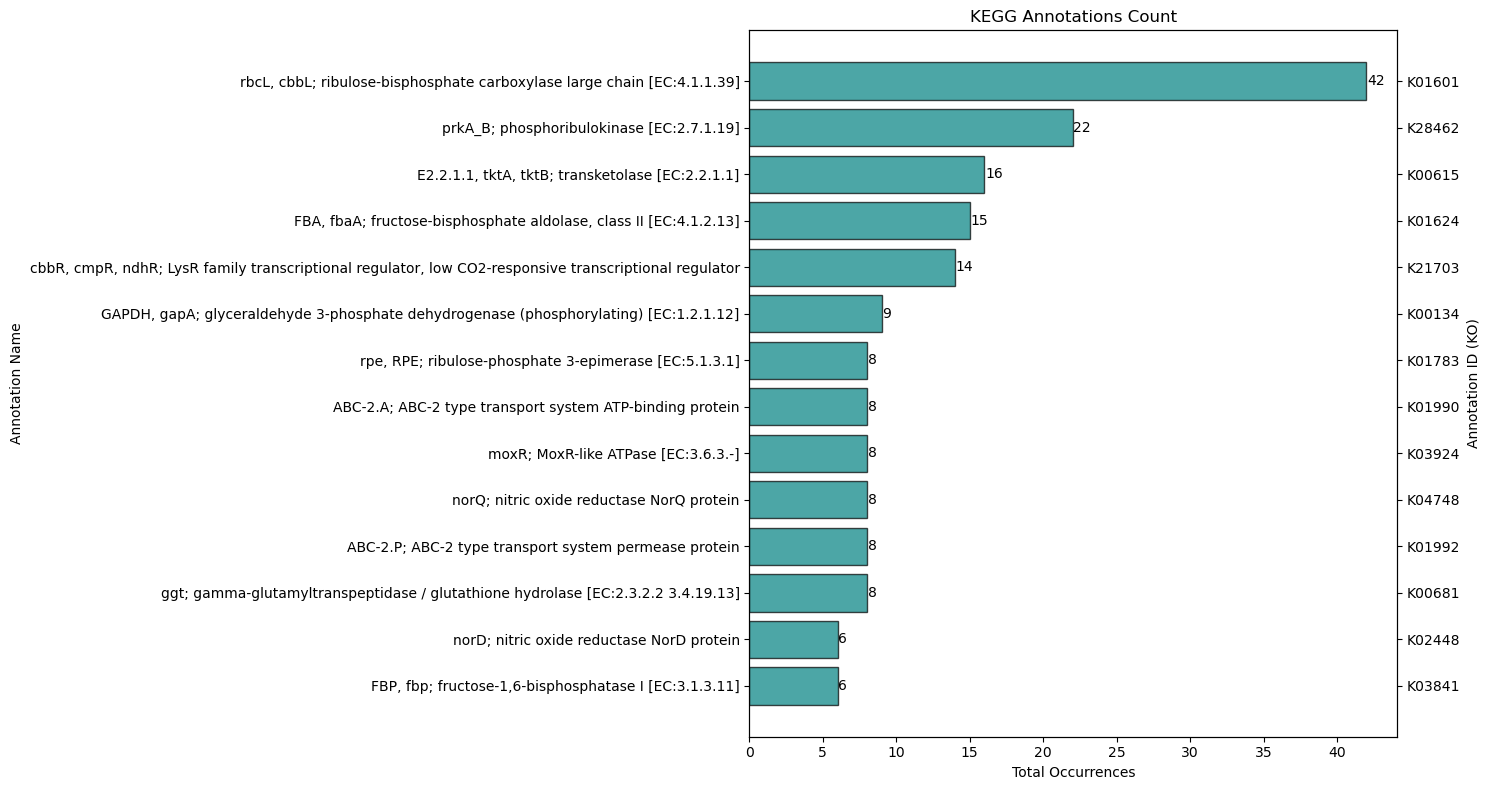

In [44]:
# 1. Group by both ID and Name to count occurrences of each term
counts = GhostKOALA.groupby(['annotation_id', 'annotation_name']).size().reset_index(name='count')
counts = counts[counts['count']>5]
# 2. Sort by count so the most frequent terms are at the top
counts = counts.sort_values('count', ascending=True)

# 3. Truncate long names for the left axis (keeps the plot clean)
#counts['display_name'] = counts['annotation_name'].apply(lambda x: (x[:50] + '..') if len(str(x)) > 50 else x)

# 4. Create the Dual Axis Plot
fig, ax1 = plt.subplots(figsize=(15, 8))

# Main bars (Left side labels)
ax1.barh(counts['annotation_name'], counts['count'], color='teal', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Total Occurrences')
ax1.set_ylabel('Annotation Name')
ax1.set_title('KEGG Annotations Count')

# Create the Right Y-axis for IDs
ax2 = ax1.twinx()
ax2.set_ylim(ax1.get_ylim())      # Synchronize scale
ax2.set_yticks(ax1.get_yticks())  # Synchronize tick locations
ax2.set_yticklabels(counts['annotation_id']) 
ax2.set_ylabel('Annotation ID (KO)',rotation=90)

# Add the actual number on the end of each bar
for i, v in enumerate(counts['count']):
    ax1.text(v + 0.05, i, str(v), color='black', va='center')

plt.tight_layout()

In [37]:
out_label_advanced = '/scicore/home/schwede/pasqua0002/metaGCsnap/workflow/allSnap/tutorial/rubisco/advanced'

In [38]:
config.arguments['operon_cluster_advanced']['value'] = True

advanced_gc = GenomicContext(config, out_label_advanced)

advanced_gc.curr_targets = targets.all_ids
advanced_gc.update_syntenies(ncbi_gc.get_syntenies())
advanced_gc.update_syntenies(MGnify_gc.get_syntenies())

In [39]:
# detect protein familis
families = Families(config, advanced_gc, out_label_advanced, sensitivity=7.5 )
families.run()

# write protein families results
advanced_gc.update_syntenies(families.get_families())
advanced_gc.create_and_write_families_summary(families)
console.print_done('Protein families assigned')


✅  Done prepare data for MMseqs

✅  Done running MMseqs

Finding communities with Infomap

Read communities from file

✅  Done find clusters

...

✅  Done assigning families to flanking genes

✅  Done create families summary

        Found 42 conserved protein families, 3 pseudogenes and 80 non-conserved protein coding regions

✅  Done families information written to mmseqs_flanking/families_summary.json

✅  Done protein families assigned

In [40]:
# detect operons
operons = Operons(config, advanced_gc, out_label_advanced)
operons.run()

# write operons results
advanced_gc.update_syntenies(operons.get_operons())
advanced_gc.create_and_write_operon_types_summary()
advanced_gc.find_most_populated_operon_types() 

Output()

✅  Done running advanced operon clustering with PaCMAP

✅  Done create operons summary

        Found 5 operon types (out of a total of 39 input targets)

✅  Done find most populated operon types

        Selected 5 operon/genomic_context types, with most populated corresponding to GC Type 00002

✅  Done selected operon written to 
/scicore/home/schwede/pasqua0002/metaGCsnap/workflow/allSnap/tutorial/rubisco/advanced/genomic_context/results/sele
cted_operons.json

In [41]:
# detect genomic bins
binning = SourMashBinning(gc=advanced_gc, config=config)
binning.run()

# write dna binning results
advanced_gc.update_syntenies(binning.gc.syntenies)
advanced_gc.create_and_write_metagenomic_bins_summary()
advanced_gc.find_most_populated_metagenomic_bins() 

✅  Done launching SourMash binning of genomic regions

✅  Done signatures file already exists.

✅  Done similarity matrix already exists.

✅  Done distance matrix already exists.

✅  Done target level distance matrix already exists.

...

✅  Done create operons summary

        Found 26 metagenomic bins (out of a total of 39 input targets)

✅  Done find most populated operon types

        Selected 26 metagenomic bins, with most populated corresponding to Metagenomic bin 1

✅  Done selected metagenomic bins written to 
/scicore/home/schwede/pasqua0002/metaGCsnap/workflow/allSnap/tutorial/rubisco/advanced/genomic_context/results/sele
cted_metagenomic_bins.json

In [42]:
# Step 2 — draw the three-panel summary
figs = Figures(config, advanced_gc, out_label_advanced)
path = figs.run_summary()           # uses MMseqs fallback for Panel 3

BokehDeprecationWarning: 'circle() method with size value' was deprecated in Bokeh 3.4.0 and will be removed, use 
'scatter(size=...) instead' instead.

BokehDeprecationWarning: 'circle() method with size value' was deprecated in Bokeh 3.4.0 and will be removed, use 
'scatter(size=...) instead' instead.

BokehDeprecationWarning: 'circle() method with size value' was deprecated in Bokeh 3.4.0 and will be removed, use 
'scatter(size=...) instead' instead.

Output()

✅  Done creating summary figure (PaCMAP + network + CLANS)

        Summary figure saved to resume.html

In [67]:
out_label_advanced

'/scicore/home/schwede/pasqua0002/metaGCsnap/workflow/allSnap/tutorial/rubisco/advanced'